<a id="s11"></a>
# 11 · Use Case 2: Email Reply Generation (Enron + Unsloth)

**Spec:** Qwen2.5-**1.5B**-Instruct · Enron email dataset (Kaggle) · load via **Unsloth** · apply LoRA · SFTTrainer (train + save adapter) · evaluate base vs LoRA · web app.

In [1]:
%pip install -q unsloth
%pip install -q kagglehub evaluate rouge_score gradio
import torch
print("GPU:", torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/

In [ ]:
import sys
import torch
import transformers
import peft

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)

try:
    import bitsandbytes as bnb
    print("BitsAndBytes:", bnb.__version__)
except Exception as e:
    print("BitsAndBytes Error:", repr(e))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Transformers: 5.5.0
PEFT: 0.19.1
BitsAndBytes: 0.49.2


In [ ]:
!nvidia-smi

Thu Jul 16 06:22:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#Importing the email generation model from local

In [2]:
!pip uninstall -y bitsandbytes
!pip install bitsandbytes==0.46.1

Found existing installation: bitsandbytes 0.49.2
Uninstalling bitsandbytes-0.49.2:
  Successfully uninstalled bitsandbytes-0.49.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 10.3 MB/s eta 0:00:00


In [ ]:
import bitsandbytes as bnb
print(bnb.__version__)

0.46.1


##Importing model

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from transformers import BitsAndBytesConfig
from unsloth import FastLanguageModel

# Original MODEL_ID was for the 0.5B model. For the email reply task, we need the 1.5B model.
MODEL_ID = "unsloth/Qwen2.5-1.5B-Instruct" # Corrected MODEL_ID
MAX_SEQ = 1024 # Needed for FastLanguageModel

# Load base model and tokenizer using Unsloth's FastLanguageModel
# This replaces the AutoTokenizer and AutoModelForCausalLM calls.
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_ID,
    max_seq_length = MAX_SEQ,
    load_in_4bit   = True, # This handles the 4-bit quantization part
)

# Load the trained PEFT adapter onto the base_model from Unsloth
model = PeftModel.from_pretrained(
    base_model,
    "/content/email_reply_lora_adapter"
)

model.eval()

print("Email Reply LoRA model loaded successfully.")

KeyboardInterrupt: 

In [ ]:
!pip install -U bitsandbytes>=0.46.1

## 11.1 · Load the base model with Unsloth (Steps 1 & 3)
Unsloth's `FastLanguageModel` loads Qwen2.5-1.5B-Instruct in 4-bit with its optimized kernels (~2× faster training, ~50% less VRAM than vanilla PEFT). Unsloth also patches the model for fp16-safe computation on the T4 — the overflow issue we hit in Section 5.2 is handled internally.

In [3]:
from unsloth import FastLanguageModel

MAX_SEQ = 1024   # emails are longer than SQL rows

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length = MAX_SEQ,
    load_in_4bit   = True,
)
print("Base model loaded.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.7.3: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Base model loaded.


## 11.2 · Enron dataset → (incoming email → reply) pairs (Step 2)
The Enron corpus (517k raw corporate emails) is downloaded via `kagglehub` (no Kaggle login needed for public datasets). Raw messages are not paired, so we construct supervision pairs from **reply emails**: any message containing the `-----Original Message-----` marker contains both the reply (before the marker) and the email being replied to (after it). We parse, clean headers, filter by length, and keep 4,000 train / 100 held-out pairs.

In [4]:
import kagglehub, pandas as pd, email as email_lib, re, random
from datasets import Dataset
import re as _re
from datasets import load_dataset as _load_dataset

random.seed(7)

path = kagglehub.dataset_download("wcukierski/enron-email-dataset")
CSV = f"{path}/emails.csv"
print("Dataset at:", CSV)

MARKER  = "-----Original Message-----"
SIGNOFF = re.compile(r"^(thanks|thank you|regards|best|best regards|cheers|thx)\b[.,!]?$", re.I)

def clean_original(text):
    lines = []
    for l in text.strip().splitlines():
        l = re.sub(r"^\s*>+\s*", "", l)
        if re.match(r"^\s*(From|Sent|To|Cc|Subject)\s*:", l):
            continue
        l = re.sub(r"\[mailto:[^]]+\]", "", l)
        lines.append(l)
    return " ".join(" ".join(lines).split())

def clean_reply(text):
    lines = [l.strip() for l in text.strip().splitlines() if l.strip()]
    while lines and (len(lines[-1].split()) <= 3 or SIGNOFF.match(lines[-1])):
        lines.pop()
    return " ".join(" ".join(lines).split())

def extract_pairs(chunk):
    out = []
    for raw in chunk["message"]:
        try:
            msg  = email_lib.message_from_string(raw)
            body = msg.get_payload()
            if not isinstance(body, str) or MARKER not in body:
                continue
            reply, original = body.split(MARKER, 1)
            original = clean_original(original)
            reply    = clean_reply(reply)
            subject  = re.sub(r"^\s*(RE|FW|FWD)\s*:\s*", "", (msg.get("Subject") or "").strip(), flags=re.I)
            if (150 <= len(reply) <= 1200 and 50 <= len(original) <= 1500
                    and "forwarded by" not in reply.lower()):
                out.append({"subject": subject, "incoming": original, "reply": reply})
        except Exception:
            pass
    return out

pairs = []
for chunk in pd.read_csv(CSV, chunksize=20000):
    pairs += extract_pairs(chunk)
    # The dataset provides 16338 pairs, which is less than the original target of 30200.
    # Therefore, the `break` condition `if len(pairs) >= 30200:` will not be met,
    # and all available pairs will be collected.

print(f"pairs collected: {len(pairs)}")

# Adjusting the train/eval split to reflect the actual number of collected pairs (16338).
# Using the last 100 pairs for evaluation, consistent with original comment intention.
num_eval_samples = 100

if len(pairs) > num_eval_samples:
    train_pairs = pairs[:-num_eval_samples]
    eval_pairs = pairs[-num_eval_samples:]
else:
    # If less than 100 pairs are collected, use all for eval and none for train (edge case)
    train_pairs = []
    eval_pairs = pairs # This case won't be hit with 16338 pairs

# ---------------- load & reformat Bitext customer support ----------------
bitext_raw = _load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset", split="train")

def bitext_to_pair(row):
    subject = row["intent"].replace("_", " ").title()
    return {"subject": subject, "incoming": row["instruction"].strip(),
            "reply": row["response"].strip(), "domain": "customer_support"}

bitext_pairs = [bitext_to_pair(r) for r in bitext_raw]
print(f"Bitext pairs: {len(bitext_pairs)}")

# tag Enron pairs with a domain too, for consistency
for p in train_pairs:
    p["domain"] = "general_correspondence"
for p in eval_pairs:
    p["domain"] = "general_correspondence"

# ---------------- combine (cap Bitext so it doesn't drown out Enron's voice) ----------------
random.shuffle(bitext_pairs)
TAKE_BITEXT_TRAIN = 20000   # tune this; set to len(bitext_pairs) to use all ~26.8k
bitext_train = bitext_pairs[:TAKE_BITEXT_TRAIN]
bitext_eval  = bitext_pairs[TAKE_BITEXT_TRAIN:TAKE_BITEXT_TRAIN + 100]

combined_train_pairs = train_pairs + bitext_train
combined_eval_pairs  = eval_pairs + bitext_eval
random.shuffle(combined_train_pairs)

print(f"Combined train: {len(combined_train_pairs)}  (Enron {len(train_pairs)} + Bitext {len(bitext_train)})")
print(f"Combined eval : {len(combined_eval_pairs)}")

train_pairs = combined_train_pairs   # downstream cells (to_text_augmented, etc.) use this name unchanged
eval_pairs  = combined_eval_pairs

EMAIL_PROMPT = (
    "You are a professional corporate email assistant. Write a professional, "
    "polite and concise reply to the incoming email.\n"
    "### Subject:\n{subject}\n### Incoming Email:\n{incoming}\n### Reply:\n"
)
INTENT_MARKER = "### The reply should convey: {intent}\n### Reply:"

STOPWORDS = set("the a an and or but if of to in on at for with from is are was were be been being "
                "this that these those i you we they he she it will would can could should shall".split())

def pseudo_intent(reply: str) -> str:
    """Keyword-bag intent — NOT a grammatical prefix of the reply, so the model
    must compose a real sentence around it instead of just continuing it verbatim."""
    words = _re.findall(r"[a-zA-Z']{4,}", reply.lower())
    keywords, seen = [], set()
    for w in words:
        if w not in STOPWORDS and w not in seen:
            keywords.append(w); seen.add(w)
        if len(keywords) == 5:
            break
    random.shuffle(keywords)  # break any residual left-to-right ordering cue
    return "mention " + ", ".join(keywords) if keywords else "acknowledge the message"

def to_text_augmented(p):
    prompt = EMAIL_PROMPT.format(subject=p["subject"], incoming=p["incoming"])
    if random.random() < 0.5:
        intent = pseudo_intent(p["reply"])
        prompt = prompt.replace("### Reply:", INTENT_MARKER.format(intent=intent))
    return {"text": prompt + p["reply"] + tokenizer.eos_token}

email_train = Dataset.from_list([to_text_augmented(p) for p in train_pairs])
print(email_train)
print("-"*70)
print(email_train[0]["text"][:900])
print("-"*70)
print(email_train[1]["text"][:900])   # should show an intent-augmented example most of the time

100%|██████████| 358M/358M [00:02<00:00, 145MB/s]

Extracting files...


Dataset at: /root/.cache/kagglehub/datasets/wcukierski/enron-email-dataset/versions/2/emails.csv
pairs collected: 16338


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Bitext pairs: 26872
Combined train: 36238  (Enron 16238 + Bitext 20000)
Combined eval : 200
Dataset({
    features: ['text'],
    num_rows: 36238
})
----------------------------------------------------------------------
You are a professional corporate email assistant. Write a professional, polite and concise reply to the incoming email.
### Subject:
Black Diamond Energy Contact
### Incoming Email:
Chris, I spoke with Eric yesterday and he said that you did a great sales job and he wants to try to work with Enron. He is marketing his gas through John Bower of Natural Gas Associates. No one here is too impressed with NGA and have visited with them before on behalf of other clients but will meet with John this afternoon to discuss Black Diamond's needs. From Eric it sounds like they want gas purchases in addition to other physical services. If that is the case we will bring Mark Whitt's group in on the deal. I will keep you informed as to the progress. Mike Legler will likely be taking t

## 11.3 · Apply LoRA (Step 4)
Same recipe as the SQL adapter: r = 16, α = 32, attention projections. `lora_dropout = 0` because Unsloth's fast kernels are optimized for the dropout-free path (our dataset is large enough not to need it). Note the trainable % — compare it with the 0.4359% of Use Case 1.

In [5]:
model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    lora_alpha     = 32,
    lora_dropout   = 0.05,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"],
    bias           = "none",
    use_gradient_checkpointing = "unsloth",
    random_state   = 42,
)
model.print_trainable_parameters()

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.7.3 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 4,358,144 || all params: 1,548,072,448 || trainable%: 0.2815


## 11.4 · Train and save the adapter (Step 5)
Effective batch 8 (2 × 4 accumulation — the 1.5B model at 1,024-token sequences needs the smaller per-device batch on a T4). Unsloth picks fp16/bf16 automatically for the hardware. Expect roughly 25–45 minutes.

In [6]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported

kw = dict(
    output_dir="qwen15b-email-lora",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=1, # Changed from 1 to 2
    learning_rate=1e-4, # Changed from 2e-4 to 1e-4
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    fp16=not is_bfloat16_supported(),
    bf16=is_bfloat16_supported(),
    logging_steps=20,
    save_steps=200,
    optim="adamw_8bit",
    report_to="none",
    dataset_text_field="text",
)
try:                                   # TRL argument rename compatibility
    cfg = SFTConfig(max_seq_length=MAX_SEQ, **kw)
except TypeError:
    cfg = SFTConfig(max_length=MAX_SEQ, **kw)

try:                                   # tokenizer -> processing_class rename compatibility
    trainer = SFTTrainer(model=model, tokenizer=tokenizer, args=cfg, train_dataset=email_train)
except TypeError:
    trainer = SFTTrainer(model=model, processing_class=tokenizer, args=cfg, train_dataset=email_train)

email_result = trainer.train()
print(f"Training complete — {email_result.metrics['train_runtime']/60:.1f} min, "
      f"final loss {email_result.metrics['train_loss']:.4f}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/36238 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 36,238 | Num Epochs = 1 | Total steps = 2,265
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 4,358,144 of 1,548,072,448 (0.28% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
20,2.795912
40,2.522846
60,2.187833
80,1.965822
100,1.962916
120,1.903020
140,1.900475
160,1.973323
180,1.894224
200,1.806937


Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora/checkpoint-800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora/checkpoint-1200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora/checkpoint-1400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora/checkpoint-1600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora/checkpoint-1800/tokenizer_config.json.
Unsloth: Restored added

Training complete — 94.8 min, final loss 1.7087


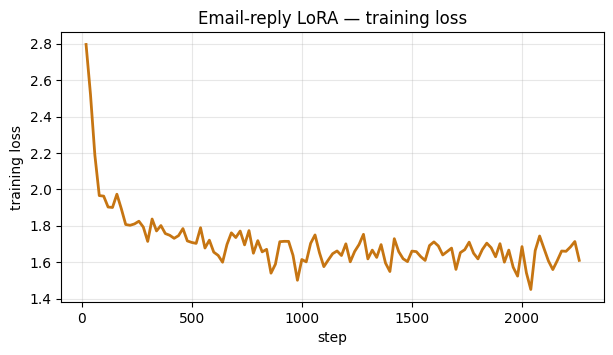

Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora-adapter/tokenizer_config.json.


Adapter saved to 'qwen15b-email-lora-adapter'  (28.9 MB)


In [7]:
import os
import matplotlib.pyplot as plt

hist = [(h["step"], h["loss"]) for h in trainer.state.log_history if "loss" in h]
s, l = zip(*hist)
plt.figure(figsize=(7,3.5)); plt.plot(s, l, color="#C67512", linewidth=2)
plt.xlabel("step"); plt.ylabel("training loss"); plt.title("Email-reply LoRA — training loss")
plt.grid(alpha=.3); plt.savefig("email_loss_curve.png", dpi=150, bbox_inches="tight"); plt.show()

EMAIL_ADAPTER = "qwen15b-email-lora-adapter"
model.save_pretrained(EMAIL_ADAPTER)
tokenizer.save_pretrained(EMAIL_ADAPTER)
mb = sum(os.path.getsize(os.path.join(EMAIL_ADAPTER, f)) for f in os.listdir(EMAIL_ADAPTER)) / 1e6
print(f"Adapter saved to '{EMAIL_ADAPTER}'  ({mb:.1f} MB)")

## 11.5 · Evaluation — base vs LoRA (Step 6)
Email replies have no single “correct answer”, so exact match is meaningless here. The standard for generation is **ROUGE** overlap with the reference reply (ROUGE-1 = word overlap, ROUGE-L = longest common subsequence), plus qualitative side-by-side reading. Both outputs come from the **same loaded model** — `disable_adapter()` gives the base behavior, exactly as in Use Case 1.

In [8]:
import evaluate
from tqdm.auto import tqdm

FastLanguageModel.for_inference(model)   # Unsloth 2x-faster inference mode

def generate_reply(subject, incoming, use_adapter=True,
                   max_new_tokens=256, temperature=0.4, top_p=0.9): # Updated params
    prompt = EMAIL_PROMPT.format(subject=subject, incoming=incoming[:1500]) # Corrected 'email' to 'incoming'
    ids = tokenizer(prompt, return_tensors="pt").to(model.device)
    ctx = model.disable_adapter() if not use_adapter else torch.no_grad()
    with ctx, torch.no_grad():
        out = model.generate(**ids, max_new_tokens=max_new_tokens,
                             do_sample=True, temperature=temperature, top_p=top_p, # Added do_sample, temp, top_p
                             pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id)

    # Decode only the generated part, excluding the input prompt
    generated_ids = out[0][ids["input_ids"].shape[1]:]
    text = tokenizer.decode(generated_ids, skip_special_tokens=True)

    # Return only the cleaned reply, stripping any remaining prompt markers
    return text.split("Reply:")[-1].strip()

rouge = evaluate.load("rouge")
N_EVAL = 50
preds = {"base": [], "lora": []}
refs  = []

for p in tqdm(eval_pairs[:N_EVAL], desc="evaluating"):
    refs.append(p["reply"])
    preds["base"].append(generate_reply(p["subject"], p["incoming"], use_adapter=False))
    preds["lora"].append(generate_reply(p["subject"], p["incoming"], use_adapter=True))

print(f"\n{'model':8}{'ROUGE-1':>10}{'ROUGE-L':>10}")
scores = {}
for m in ("base", "lora"):
    r = rouge.compute(predictions=preds[m], references=refs)
    scores[m] = r
    print(f"{m:8}{r['rouge1']:>10.3f}{r['rougeL']:>10.3f}")

evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=2


model      ROUGE-1   ROUGE-L
base         0.178     0.103
lora         0.165     0.102


In [9]:
# qualitative side-by-side (screenshot these for the report)
for i in range(3):
    p = eval_pairs[i]
    print("="*90)
    print(f"SUBJECT : {p['subject']}")
    print(f"INCOMING: {p['incoming'][:220]}...")
    print(f"\nACTUAL ENRON REPLY:\n{p['reply'][:350]}")
    print(f"\nBASE MODEL:\n{preds['base'][i][:350]}")
    print(f"\nLoRA MODEL:\n{preds['lora'][i][:350]}")

SUBJECT : PRC Pre-Ranking Meeting EOL
INCOMING: Kate, I have reserved and confirmed conference room EB2626 from 11:00 - 1:00 pm CST, for PRC Pre-Ranking meeting on June 8, 2001. Yvonne, please let me know if you need additional information for this scheduled video con...

ACTUAL ENRON REPLY:
Dear all, Friday's PRC meeting has had to be rescheduled so I can VC Andy in from Houston. It will now be 5 - 7pm on 8 June UK time and 11am - 1pm US time. Can you all check your calenders to make sure this is correct. It will still be held in RM SE5005 for London attendees.

BASE MODEL:
Dear Kate,
Thank you for reserving the conference room. Is there anything else we need to confirm or any additional information that needs to be shared? 
Best regards,
Lydia Cannon

LoRA MODEL:
Lydia, I will be in the office until about 1:00 PM. Can you send me the details of the meeting?
SUBJECT : Message from AT&T High Speed Packet Services PM
INCOMING: FYI -----Original Message----- June 04, 2001 ENRON CORPORATI

## 11.6 · Web app (Step 7)
Same side-by-side pattern as the SQL app: paste an incoming email, get the base model's reply and the LoRA model's reply next to each other. `share=True` gives the public demo link.

In [17]:
import gradio as gr
import torch
import re

def build_prompt(subject, incoming, intent):
    prompt = EMAIL_PROMPT.format(subject=subject, incoming=incoming[:1500])
    if intent.strip():
        prompt = prompt.replace("### Reply:", INTENT_MARKER.format(intent=intent.strip()))
    return prompt

def extract_reply(full_text: str) -> str:
    idx = full_text.rfind("### Reply:")
    reply = full_text[idx + len("### Reply:"):].strip() if idx != -1 else full_text.strip()
    cut = re.search(r"\n\s*(Subject\s*:|Incoming Email\s*:|###|Note\s*:)", reply)
    if cut:
        reply = reply[:cut.start()].strip()
    # NEW: cut at a second greeting (case-insensitive) — catches restart/hallucination loops
    greetings = list(re.finditer(r"\b(Dear\s+\w+|Hi\s+\w+|Hello\s+\w+)\b[,.]", reply, re.I))
    if len(greetings) > 1:
        reply = reply[:greetings[1].start()].strip()
    return reply

def generate_reply_intent(subject, incoming, intent="", use_adapter=True, max_new_tokens=180):
    prompt = build_prompt(subject, incoming, intent)
    ids = tokenizer(prompt, return_tensors="pt").to(model.device)
    ctx = model.disable_adapter() if not use_adapter else torch.no_grad()
    with ctx, torch.no_grad():
        out = model.generate(**ids, max_new_tokens=max_new_tokens, min_new_tokens=25,
                     do_sample=False, repetition_penalty=1.1, no_repeat_ngram_size=3,
                     pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id)
    full = tokenizer.decode(out[0], skip_special_tokens=True)
    return extract_reply(full)

tests = [
    ("Meeting reschedule request",
     "Hi, can we move our project review from Thursday to next week? Some finance reports are still being finalized.",
     "agree to reschedule, propose Tuesday 10 AM"),
    ("Invoice discrepancy",
     "We noticed invoice #4417 bills us for 120 hours but our records show 95. Can you clarify?",
     "acknowledge the issue, promise a corrected invoice by Friday"),
]
for subj, body, intent in tests:
    print("="*80)
    print("INTENT:", intent)
    print("LoRA  :", generate_reply_intent(subj, body, intent))
    print("BASE  :", generate_reply_intent(subj, body, intent, use_adapter=False)[:300])

Both `max_new_tokens` (=180) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


INTENT: agree to reschedule, propose Tuesday 10 AM


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=180) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


LoRA  : Agreed! I will propose this on Tuesday at 11am. Let me know if you have any other questions or concerns.


Both `max_new_tokens` (=180) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASE  : Dear [Name],
Thank you for reaching out with your request regarding the rescheduling of our project meeting on Thursday. I understand that some finance reports need finalizing before proceeding with the meeting, but given this delay in the schedule, I am happy to accommodate the change. We will now 
INTENT: acknowledge the issue, promise a corrected invoice by Friday


Both `max_new_tokens` (=180) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


LoRA  : I will correct it on Friday morning. I am sorry that this has caused any confusion. We appreciate your patience while we work through this matter.
BASE  : Dear [Name],
Thank you for bringing this to our attention. We apologize for any confusion regarding your invoice. Please find attached an updated version that corrects the billing amount. We aim to have it reviewed and approved by Friday at the latest. If there is anything else we can assist with, p


In [18]:
def compare_replies(subject, incoming, intent):
    return (generate_reply_intent(subject, incoming, intent, use_adapter=False),
            generate_reply_intent(subject, incoming, intent, use_adapter=True))

with gr.Blocks(title="LoRA Email Reply Assistant") as email_app:
    gr.Markdown("## Professional Email Reply Generator — base vs LoRA fine-tuned (Enron corpus)\n"
                "*Same frozen Qwen2.5-1.5B base; the only difference between the two panes is a small "
                "LoRA adapter, retrained to understand an optional intent instruction.*")
    subj = gr.Textbox(label="Subject", value="Meeting reschedule request")
    body = gr.Textbox(label="Incoming email", lines=6, value=(
        "Hi, I wanted to check if we could move our project review meeting from Thursday "
        "to early next week. A few of the finance reports we need are still being finalized."))
    intent = gr.Textbox(label="What should the reply say? (optional)",
                        placeholder="e.g. agree to reschedule, propose Tuesday 10 AM")
    btn = gr.Button("Generate reply", variant="primary")
    with gr.Row():
        out_b = gr.Textbox(label="Base model reply", lines=10)
        out_l = gr.Textbox(label="LoRA fine-tuned reply", lines=10)
    btn.click(compare_replies, [subj, body, intent], [out_b, out_l])
    gr.Examples(
        [["Meeting reschedule request",
          "Hi, I wanted to check if we could move our project review meeting from Thursday to early next week.",
          "agree to reschedule, propose Tuesday 10 AM"],
         ["Status update request",
          "Could you give me a quick update on where we stand with the Phoenix contract review?",
          "review is nearly done, summary will be sent Thursday"],
         ["Document request",
          "Please send me the latest version of the Q3 operating statement when you get a chance.",
          ""]],
        [subj, body, intent])

email_app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7ec6c281c35cc32f3e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 11.7 · Notes for the report
- **Steps ↔ cells:** 1 & 3 → §11.1 (Unsloth load) · 2 → §11.2 (Enron pairing) · 4 → §11.3 · 5 → §11.4 · 6 → §11.5 · 7 → §11.6.
- **Why pairs from `-----Original Message-----`:** Enron is a raw corpus, not an instruction dataset; reply-quoting messages contain both sides of an exchange, giving genuine (incoming → human reply) supervision in an authentic corporate voice — exactly the “organization's writing style” the use case targets.
- **Why ROUGE, not accuracy:** open-ended generation has many valid replies; overlap with the real human reply + qualitative reading is the honest evaluation. Expect modest absolute ROUGE with LoRA > base; the qualitative difference (structure, tone, sign-off, brevity) is the headline.
- **Caveats to state:** Enron emails are from 1999–2002 (dated conventions, real names in data); replies before the marker sometimes include signatures/noise despite filtering; one seed, one epoch.

In [12]:
# ============================================================
# Save LoRA Adapter
# ============================================================

SAVE_DIR = "/content/email_reply_lora_adapter"

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print("=" * 60)
print("LoRA adapter saved successfully.")
print(f"Location : {SAVE_DIR}")
print("=" * 60)

Unsloth: Restored added_tokens_decoder metadata in /content/email_reply_lora_adapter/tokenizer_config.json.


LoRA adapter saved successfully.
Location : /content/email_reply_lora_adapter


In [13]:
# ============================================================
# Create ZIP File
# ============================================================

import shutil

shutil.make_archive(
    "/content/email_reply_lora_adapter",
    "zip",
    SAVE_DIR
)

print("ZIP file created successfully.")

ZIP file created successfully.


In [14]:
from google.colab import files

files.download("/content/email_reply_lora_adapter.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>